In [4]:
import numpy as np
import matplotlib.pyplot as plt
from utils import tx_rx_system
import math

## Anàlisi de l'Emisor

En aquesta etapa del projecte, ens centrem en el comportament del senyal enviat pel nostre LED driver. L'objectiu és validar que el circuit respon correctament a la freqüència de treball.

### 1. Generació del Senyal de Pols (1 kHz)

Per començar l'anàlisi, simulem la transmissió d'un senyal quadrat. Aquest senyal representa les dades digitals que volem transmetre.
Paràmetres de la Simulació:
- Freqüència: $1\text{ kHz}$ (període de $1\text{ ms}$).
- Amplitud: $3.3\text{ V}$ (nivell lògic estàndard).
- Cicle de treball (Duty Cycle): $50\%$.

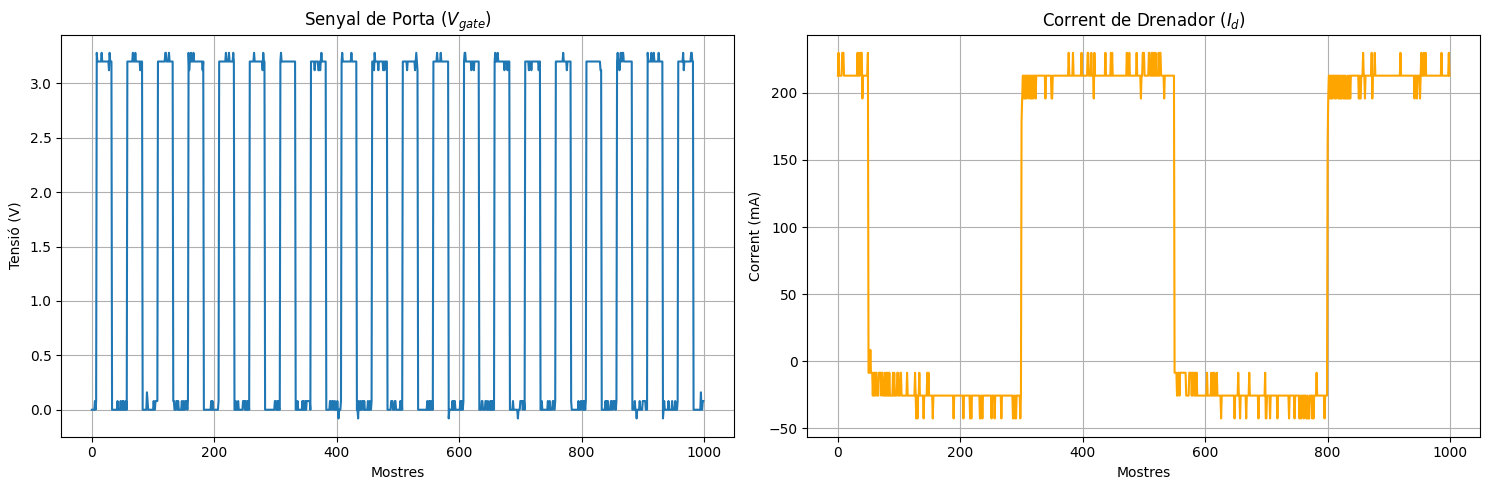

In [2]:
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_V_gate.csv", "fitxers/1kHz_V_gate_neta.csv", channels=1)
tx_rx_system.convertir_senyal_osciloscopi("fitxers/1kHz_Id.csv", "fitxers/1kHz_Id_neta.csv", channels=1)

signal_gate = np.loadtxt("fitxers/1kHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1kHz_Id_neta.csv", delimiter=',')

resistencia = 4.7  # Ohms -- L'has mesurada?! 
signal_Id = ((5 - v_mesurada) / resistencia) * 1000  # Els 5V els has mesurat? A tenir en compte: Això és mesura indirecte de la intensitat del corrent elèctric, la precisió depèn de la precisió d' V i R

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(signal_gate[:1000])
ax1.set_title("Senyal de Porta ($V_{gate}$)")
ax1.set_xlabel("Mostres") # Si acaba a la memòria, estaria bé passar de mostres a temps
ax1.set_ylabel("Tensió (V)")
ax1.grid(True)

ax2.plot(signal_Id[:1000], color='orange')
ax2.set_title("Corrent de Drenador ($I_d$)")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True)
plt.tight_layout()
plt.show()

#### Interpretació del resultat

### 2. Generació del Senyal de Pols (1 MHz)

En aquesta secció simulem la transmissió d'un senyal quadrat al sistema.

- Freqüència: 1 MHz.
- Amplitud: 3.3V.
- Objectiu: Demostrar que a aquesta freqüència, el voltatge $V_{gate}$ no té prou temps per carregar-se i assolir pràcticament els 3.3V.


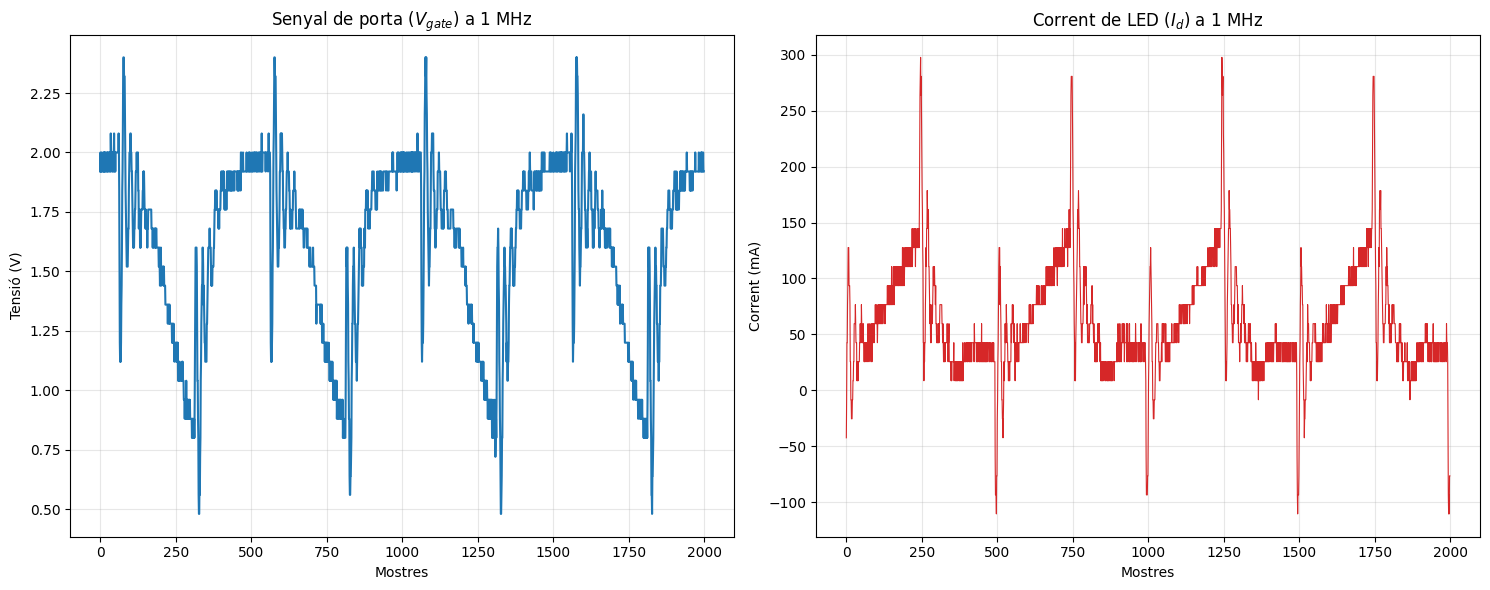

In [3]:
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_V_gate.csv",
    senyal_neta_csv="fitxers/1MHz_V_gate_neta.csv",
    channels=1
)
tx_rx_system.convertir_senyal_osciloscopi(
    senyal_csv="fitxers/1MHz_Id.csv",
    senyal_neta_csv="fitxers/1MHz_Id_neta.csv",
    channels=1
)

signal_gate = np.loadtxt("fitxers/1MHz_V_gate_neta.csv", delimiter=',')
v_mesurada = np.loadtxt("fitxers/1MHz_Id_neta.csv", delimiter=',')

signal_Id = ((5 - v_mesurada) / resistencia) * 1000
# A tenir en compte: aquí assumeixes que els "5V" no depenen de la freqüència i no és veritat
# e.g., les inducatàncies parasites (L_p) del circuit (+ la que afegeix l'oscil.) + el on-off del driver (di/dt) creen pics de corrent segons freq
# Voltage que cau a R: V(t) = I(t) * R + L_p * di(t)/dt
# La menera més precisa seria mesurar els "5V" amb l'altre canal de l'oscil.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
ax1.plot(signal_gate[:2000], color='tab:blue')
ax1.set_title("Senyal de porta ($V_{gate}$) a 1 MHz")
ax1.set_xlabel("Mostres")
ax1.set_ylabel("Tensió (V)")
ax1.grid(True, alpha=0.3)
ax2.plot(signal_Id[:2000], color='tab:red', linewidth=0.8)
ax2.set_title("Corrent de LED ($I_d$) a 1 MHz")
ax2.set_xlabel("Mostres")
ax2.set_ylabel("Corrent (mA)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Interpretació del resultat

## EXPERIMENT 1: Resposta en freq. i ample de banda EMISOR

En aquest apartat es realitza un sweep de freqüència, és a dir, una variació progressiva de la freqüència del senyal d’entrada des de 1 kHz fins a 7.5 MHz, mantenint la resta de paràmetres constants (amplitud i forma del senyal).

#### Objectiu:

L’objectiu principal és analitzar el comportament dinàmic del sistema davant diferents velocitats de commutació, i determinar fins a quina freqüència el sistema és capaç de respondre correctament.

Guardat: fitxers/BW_TX/a_neta_rx.csv i fitxers/BW_TX/a_neta_tx.csv
Guardat: fitxers/BW_TX/b_neta_rx.csv i fitxers/BW_TX/b_neta_tx.csv
Guardat: fitxers/BW_TX/c_neta_rx.csv i fitxers/BW_TX/c_neta_tx.csv
Guardat: fitxers/BW_TX/d_neta_rx.csv i fitxers/BW_TX/d_neta_tx.csv
Guardat: fitxers/BW_TX/e_neta_rx.csv i fitxers/BW_TX/e_neta_tx.csv
Guardat: fitxers/BW_TX/f_neta_rx.csv i fitxers/BW_TX/f_neta_tx.csv
Guardat: fitxers/BW_TX/g_neta_rx.csv i fitxers/BW_TX/g_neta_tx.csv
Guardat: fitxers/BW_TX/h_neta_rx.csv i fitxers/BW_TX/h_neta_tx.csv
Guardat: fitxers/BW_TX/i_neta_rx.csv i fitxers/BW_TX/i_neta_tx.csv
Guardat: fitxers/BW_TX/j_neta_rx.csv i fitxers/BW_TX/j_neta_tx.csv
Guardat: fitxers/BW_TX/k_neta_rx.csv i fitxers/BW_TX/k_neta_tx.csv
Guardat: fitxers/BW_TX/l_neta_rx.csv i fitxers/BW_TX/l_neta_tx.csv
Guardat: fitxers/BW_TX/m_neta_rx.csv i fitxers/BW_TX/m_neta_tx.csv
Guardat: fitxers/BW_TX/n_neta_rx.csv i fitxers/BW_TX/n_neta_tx.csv
Guardat: fitxers/BW_TX/o_neta_rx.csv i fitxers/BW_TX/o_neta_tx

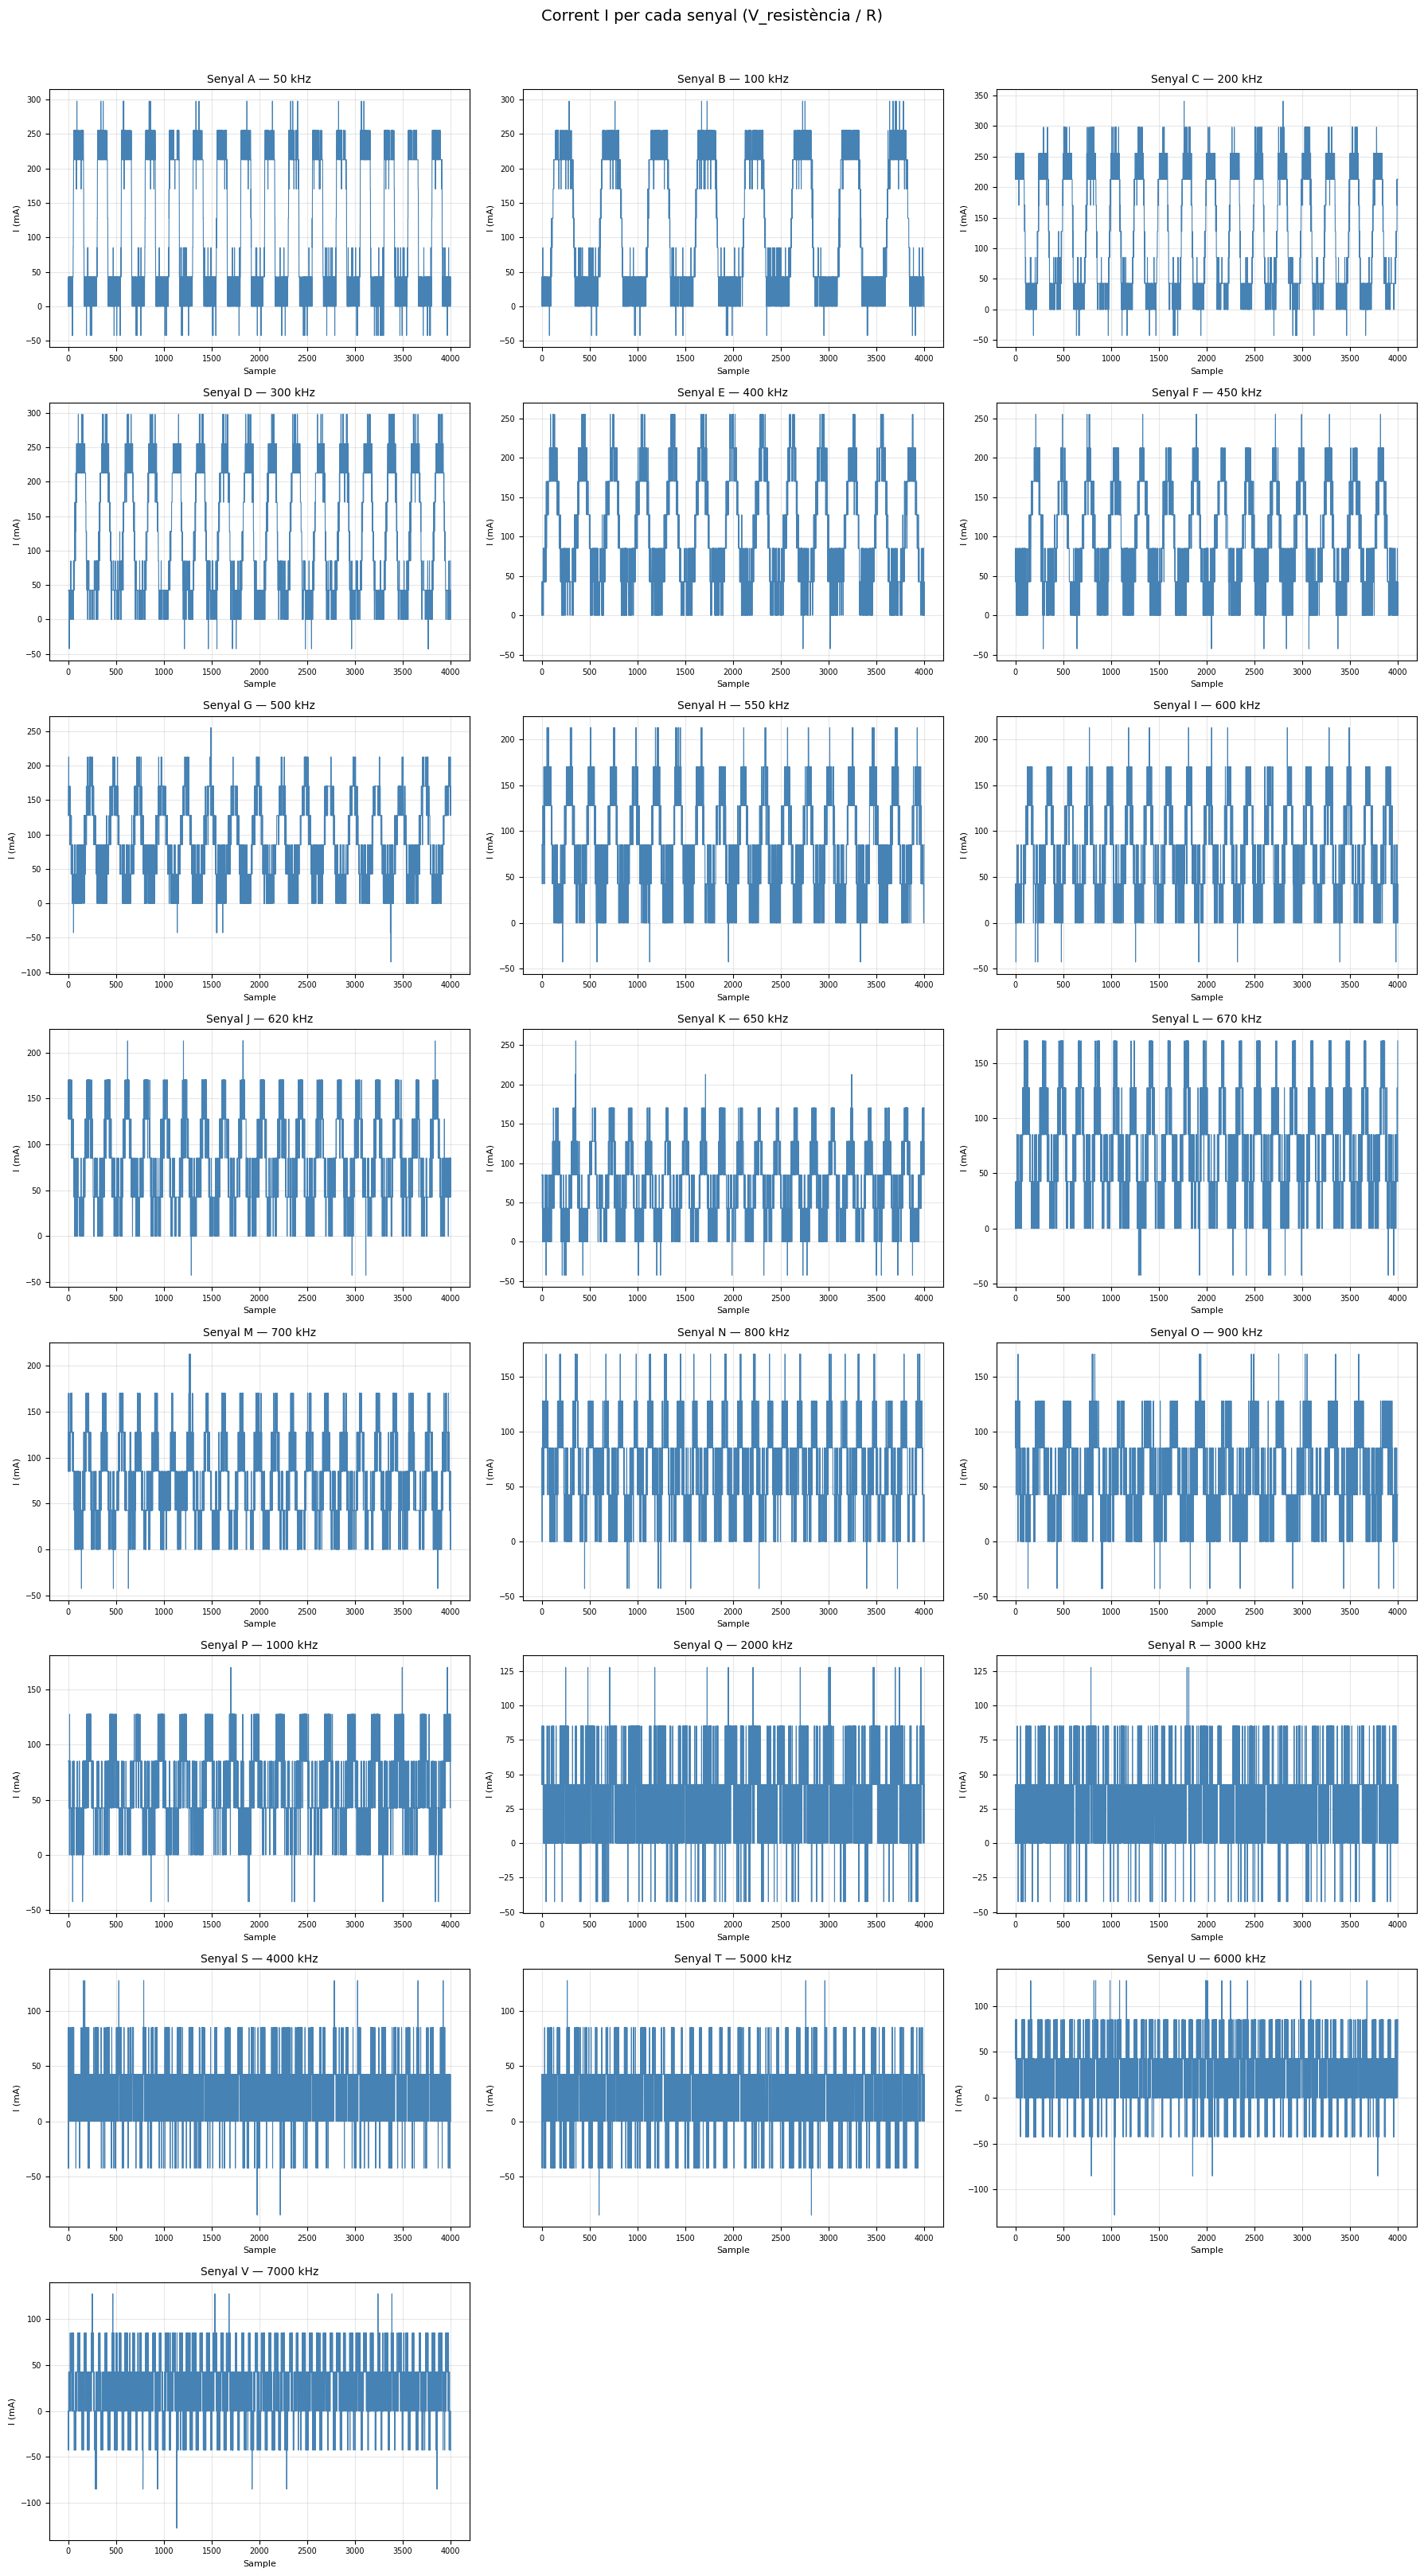

In [ ]:

senyals = ["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t", "u","v"]
freqs   = [50000,100000,200000,300000,400000,450000,500000,
           550000,600000,620000,650000,670000,700000,800000,
           900000,1000000,2000000, 3000000, 4000000, 5000000,
           6000000,7000000]

sampling_rates = [25e6,25e6,50e6,125e6,125e6,125e6,125e6,125e6,125e6,125e6,125e6,125e6,125e6,125e6,250e6,250e6,
                  500e6,500e6,500e6,500e6,500e6,500e6]
n = len(senyals)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, 4*rows))
axes = axes.flatten()

signal_Ids = []
for idx, senyal in enumerate(senyals):
    tx_rx_system.convertir_senyal_osciloscopi(
        senyal_csv=f"fitxers/BW_TX/{senyal}.csv",
        senyal_neta_csv=f"fitxers/BW_TX/{senyal}_neta.csv",
        channels=2
    )

    v_in      = np.loadtxt(f"fitxers/BW_TX/{senyal}_neta_tx.csv", delimiter=',')
    v_mesurada = np.loadtxt(f"fitxers/BW_TX/{senyal}_neta_rx.csv", delimiter=',')

    # V across resistor → current in mA
    signal_Id = ((v_in - v_mesurada) / resistencia) * 1000
    signal_Ids.append(signal_Id)
    t = np.arange(len(signal_Id))   

    ax = axes[idx]
    ax.plot(t, signal_Id, linewidth=0.8, color='steelblue')
    ax.set_title(f"Senyal {senyal.upper()} — {freqs[idx]/1e3:.0f} kHz", fontsize=10)
    ax.set_xlabel("Sample", fontsize=8)
    ax.set_ylabel("I (mA)", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

for i in range(len(senyals), len(axes)):
    axes[i].set_visible(False)

plt.suptitle("Corrent I per cada senyal (V_resistència / R)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Després del primer sweep de freqüència, s’observa que els resultats obtinguts no són del tot correctes ni representatius del comportament real del sistema.

Això es deu al fet que apareixen pics d’overshoot en el senyal de sortida, tal com es pot veure en els gràfics següents:

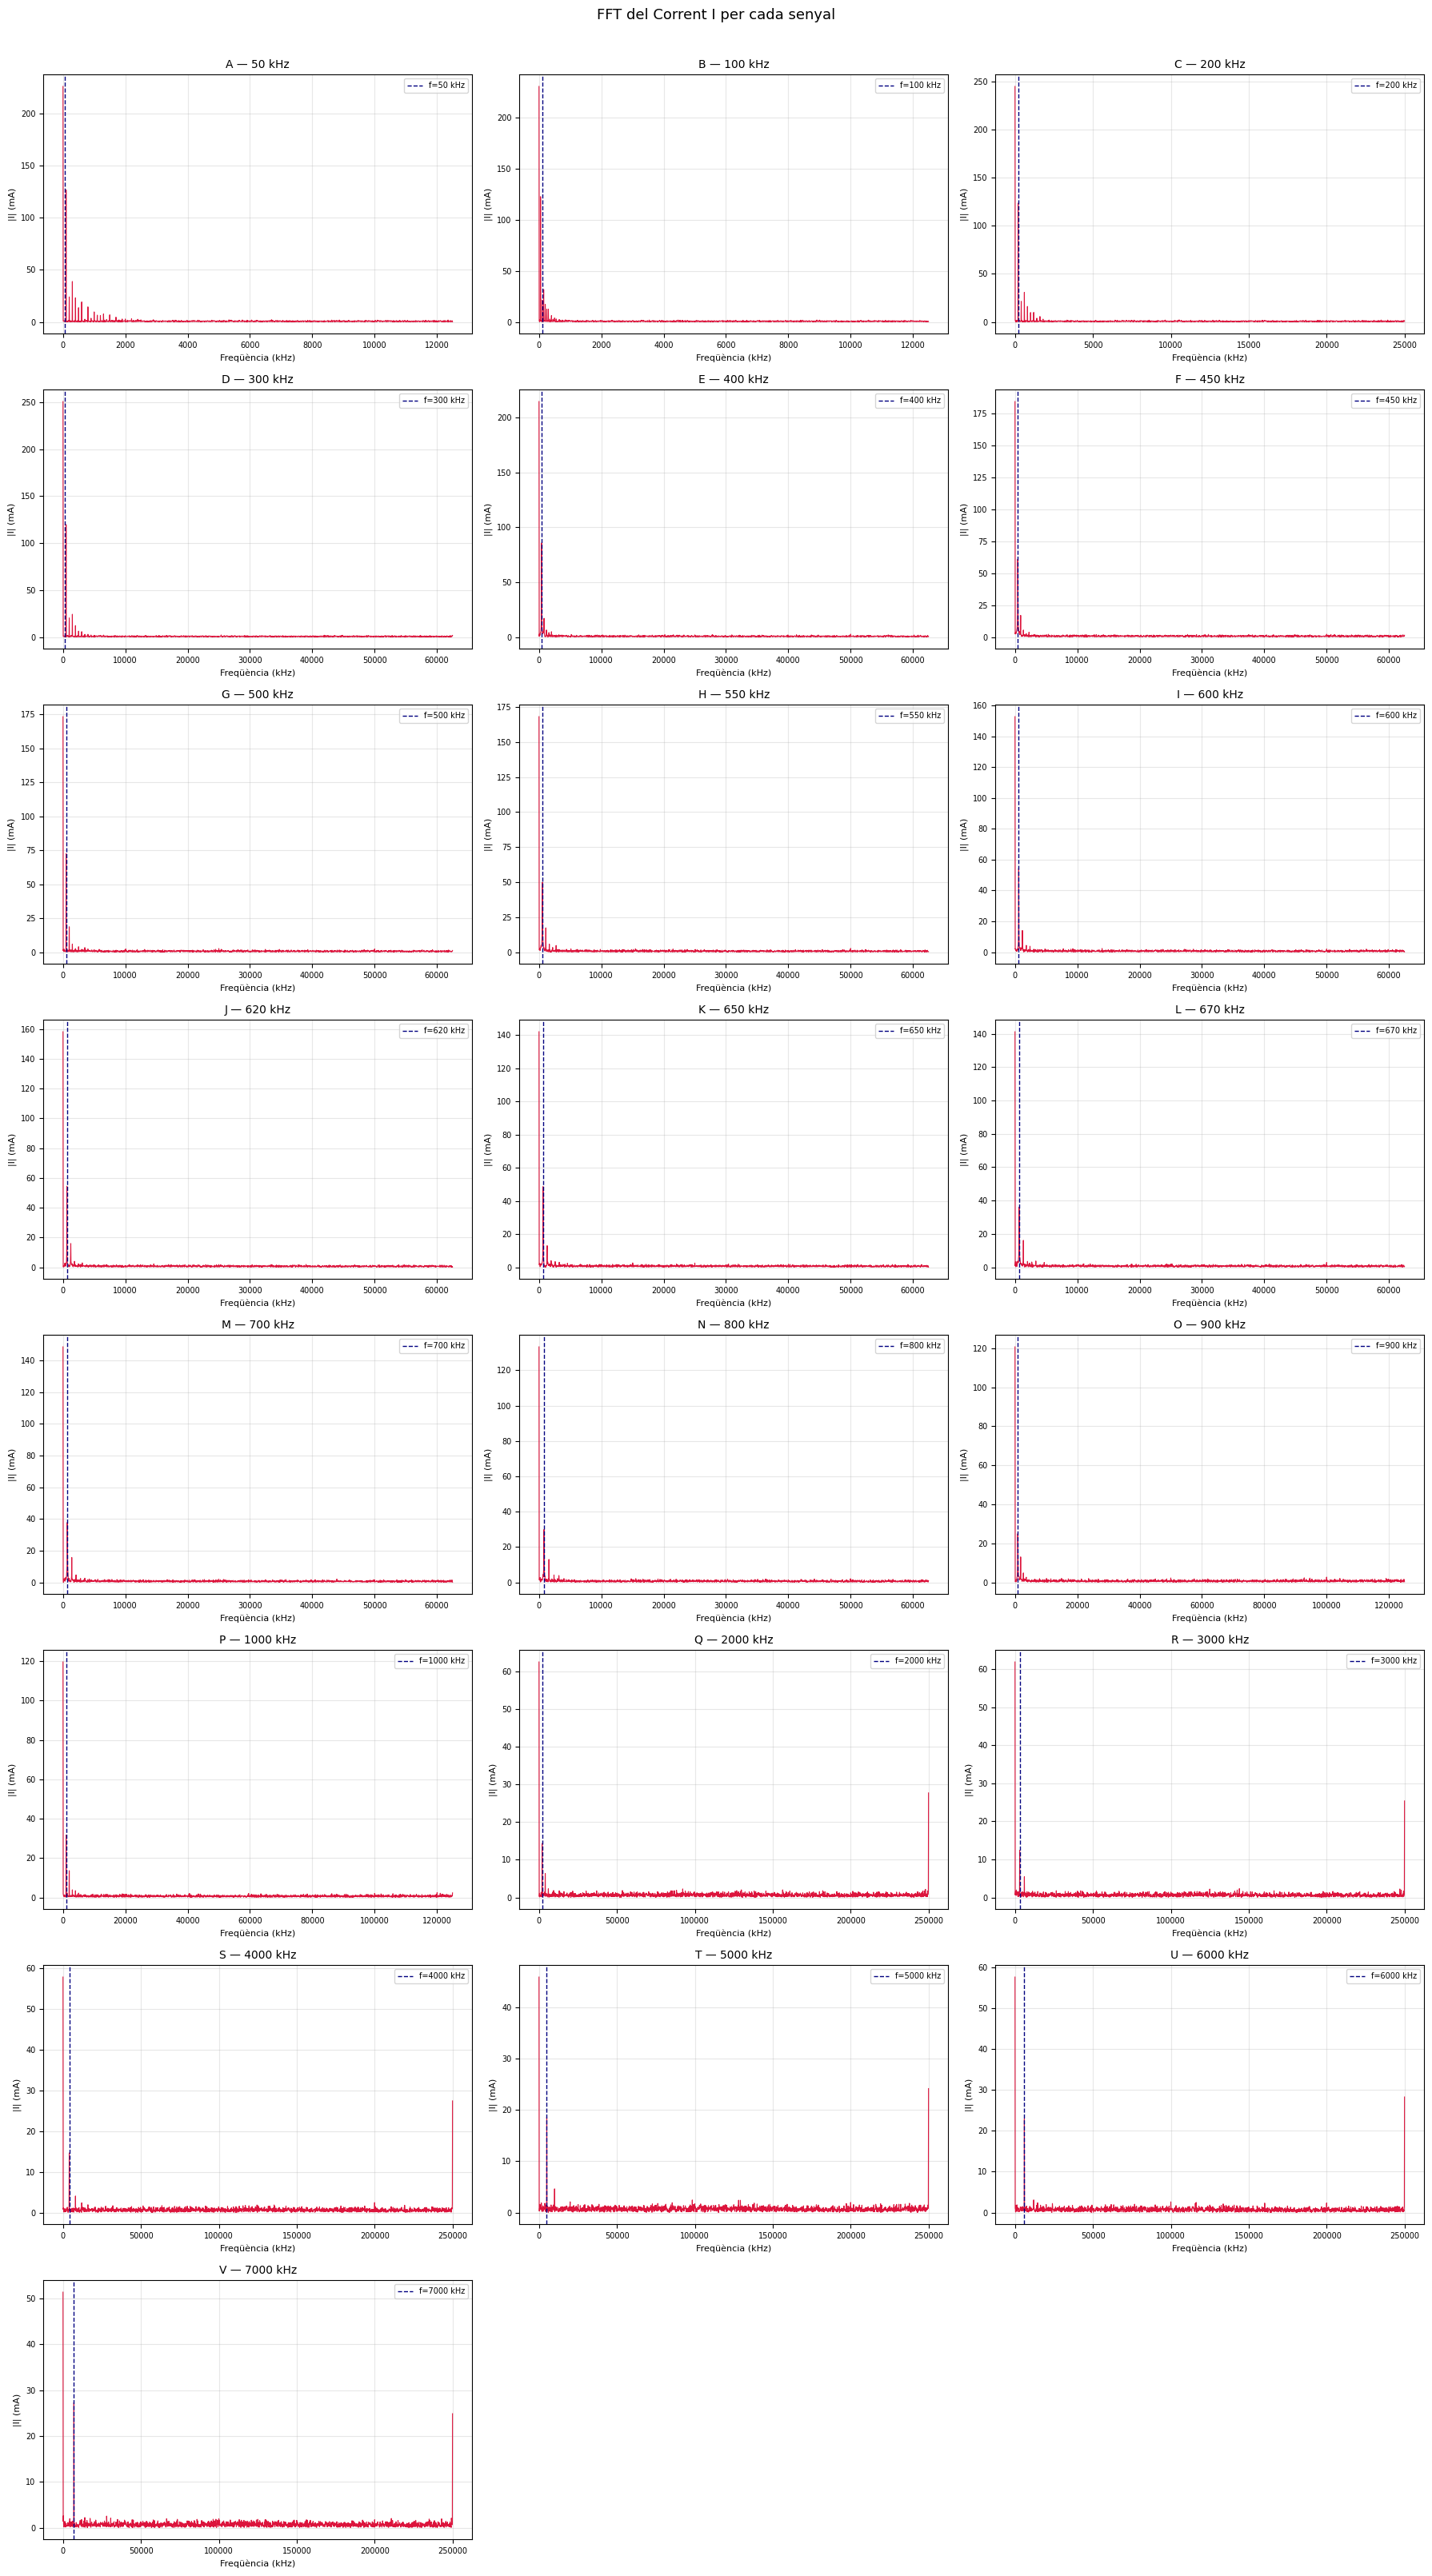

[A]      50 kHz | I_dc = 112.936 mA
[B]     100 kHz | I_dc = 115.064 mA
[C]     200 kHz | I_dc = 122.511 mA
[D]     300 kHz | I_dc = 125.426 mA
[E]     400 kHz | I_dc = 107.415 mA
[F]     450 kHz | I_dc = 92.160 mA
[G]     500 kHz | I_dc = 86.734 mA
[H]     550 kHz | I_dc = 84.096 mA
[I]     600 kHz | I_dc = 76.351 mA
[J]     620 kHz | I_dc = 79.128 mA
[K]     650 kHz | I_dc = 70.979 mA
[L]     670 kHz | I_dc = 70.660 mA
[M]     700 kHz | I_dc = 74.266 mA
[N]     800 kHz | I_dc = 66.628 mA
[O]     900 kHz | I_dc = 60.383 mA
[P]    1000 kHz | I_dc = 59.809 mA
[Q]    2000 kHz | I_dc = 31.266 mA
[R]    3000 kHz | I_dc = 30.936 mA
[S]    4000 kHz | I_dc = 28.936 mA
[T]    5000 kHz | I_dc = 22.915 mA
[U]    6000 kHz | I_dc = 28.830 mA
[V]    7000 kHz | I_dc = 25.691 mA


In [5]:
tx_rx_system.experiment1_BODE(senyals, signal_Ids, sampling_rates, freqs)

És per aquest motiu que, per tal d'obtenir una mesura més representativa del comportament real del sistema, s'opta per filtrar la component de contínua (DC) i extraient únicament l'amplitud corresponent a la freqüència fonamental del senyal d'excitació.

## EXPERIMENT 2: Ample de banda del receptor amb senyal del LED driver

Per tal de fer aquest experiment, s'ha emprat una senyal quadrada de 3.3 V amb una 
freqüència d'1 kHz. S'ha mesurat el temps de pujada (*rise time*) de la sortida del 
OPT101 amb l'oscil·loscopi, obtenint:

$$V_{max} = 2.64 \ \text{V}, \qquad V_{min} = 0 \ \text{V}$$

Els llindars del 10\% i 90\% són:

$$V_{10\%} = 0.1 \times 2.64 = 0.264 \ \text{V}$$
$$V_{90\%} = 0.9 \times 2.64 = 2.376 \ \text{V}$$

El temps de pujada mesurat entre aquests dos llindars és:

$$t_r \approx 20 \ \mu\text{s}$$

L'ample de banda del receptor s'obté a partir de la relació entre el temps de pujada 
d'un sistema de primer ordre RC i la seva freqüència de tall:

$$B = \frac{0.35}{t_r}$$

Substituint el valor mesurat:

$$B = \frac{0.35}{20 \times 10^{-6}} \approx 17.5 \ \text{kHz}$$

Aquest resultat és consistent amb el valor teòric de 14.5 kHz obtingut a partir dels 
paràmetres interns del OPT101 ($R_f = 1\ \text{M}\Omega$, $C_f = 11\ \text{pF}$):

$$B_{teoria} = \frac{1}{2\pi R_f C_f} = \frac{1}{2\pi \times 1\ \text{M}\Omega \times 11\ \text{pF}} = 14.5 \ \text{kHz}$$



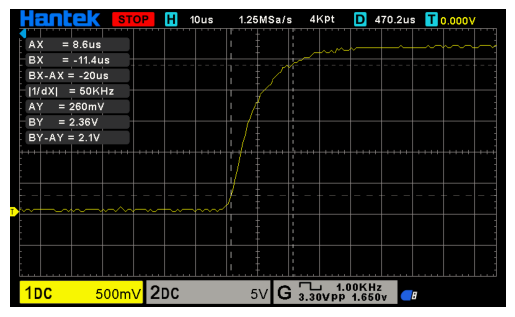

In [11]:
img = plt.imread("./fitxers/BW_receptor.bmp")
plt.imshow(img)
plt.axis("off")
plt.show()

## EXPERIMENT 3: BER vs Bitrate (Capacitat del canal)

#### Escombrar el bitrate des de valors baixos fins al límit analògic prèviament trobat. & Corba de BER vs $R_b$ i extracció del valor pràctic de $R_b^{\max}$.

Generated PRBS bits: [1, 0, 0, 0, 0, 1, 1, 1]
Samples per bit: 512
Saved signal to fitxers/prbs.csv
Executing: python3 utils/csv2arb.py fitxers/prbs.csv
Conversion complete. ARB file saved as 'fitxers/prbs.arb'.

--- EXPERIMENT 2: BER vs BITRATE ---
  a                               BER = 0.000000  (0/152 errors)  @2000 bps
  b                               BER = 0.000000  (0/120 errors)  @4000 bps
  c                               BER = 0.125000  (11/88 errors)  @6000 bps
  d                               BER = 0.125000  (15/120 errors)  @8000 bps
  e                               BER = 0.125000  (19/152 errors)  @10000 bps
  f                               BER = 0.125000  (10/80 errors)  @12000 bps
  g                               BER = 0.125000  (13/104 errors)  @14000 bps
  h                               BER = 0.250000  (30/120 errors)  @16000 bps
  i                               BER = 0.250000  (32/128 errors)  @17600 bps
  j                               BER = 0.250000  (14/56

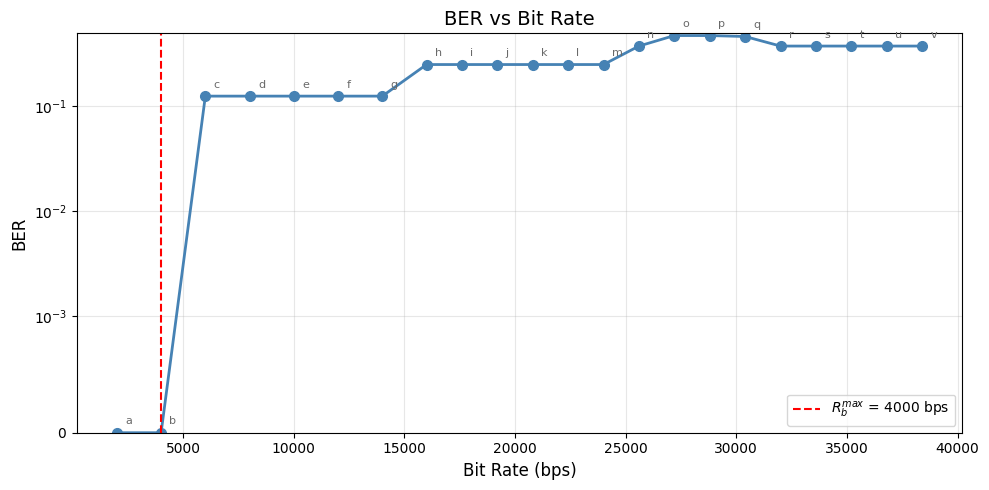

{'a': {'ber': 0.0,
  'total_errors': 0,
  'total_bits': 152,
  'bit_rate': np.float64(2000.0)},
 'b': {'ber': 0.0,
  'total_errors': 0,
  'total_bits': 120,
  'bit_rate': np.float64(4000.0)},
 'c': {'ber': 0.125,
  'total_errors': 11,
  'total_bits': 88,
  'bit_rate': np.float64(6000.0)},
 'd': {'ber': 0.125,
  'total_errors': 15,
  'total_bits': 120,
  'bit_rate': np.float64(8000.0)},
 'e': {'ber': 0.125,
  'total_errors': 19,
  'total_bits': 152,
  'bit_rate': np.float64(10000.0)},
 'f': {'ber': 0.125,
  'total_errors': 10,
  'total_bits': 80,
  'bit_rate': np.float64(12000.0)},
 'g': {'ber': 0.125,
  'total_errors': 13,
  'total_bits': 104,
  'bit_rate': np.float64(13999.999999999998)},
 'h': {'ber': 0.25,
  'total_errors': 30,
  'total_bits': 120,
  'bit_rate': np.float64(16000.0)},
 'i': {'ber': 0.25,
  'total_errors': 32,
  'total_bits': 128,
  'bit_rate': np.float64(17600.0)},
 'j': {'ber': 0.25,
  'total_errors': 14,
  'total_bits': 56,
  'bit_rate': np.float64(19200.0)},
 'k':

In [12]:
senyals = ["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t", "u","v"]
freqs   = [250,500,750,1000, 1250,1500,1750,2000,2200,2400,2600,2800,3000,3200,3400,3600,3800,4000,4200,4400,4600,4800,5000]
sampling_rates = [50e3,125e3,250e3,250e3,250e3,500e3,500e3,500e3,500e3,1.25e6,1.25e6,1.25e6,1.25e6,1.25e6,1.25e6,
                  1.25e6,1.25e6,1.25e6,1.25e6,1.25e6,1.25e6,1.25e6,1.25e6]
n_bits=8 #bits per signal
T_signals = 1/np.array(freqs)
T_bits = T_signals/n_bits
bit_rates = 1/ T_bits # taxa bits -> bits per second
time_per_sample = 1/np.array(sampling_rates)
bits_per_sample = T_bits / time_per_sample

tx_rx_system.generate_prbs_4096(n_bits=n_bits) 
tx_rx_system.experiment2_BERvsBitrate(tx_signal_sequence= [1, 0, 0, 0, 0, 1, 1, 1], rx_signals=senyals, bits_per_sample_rx=bits_per_sample, bit_rates=bit_rates)

